### NYC Taxi Trip Duration
- Predict the NYC Taxi Trip Duration - Data Science Project

In [626]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

In [627]:
pd.set_option('display.max_columns', None)

In [628]:
df = pd.read_csv('NYC.csv')

In [629]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
715324,id2821066,1,2016-06-15 20:08:30,2016-06-15 20:23:39,1,-73.997887,40.760540,-73.978630,40.752327,N,909
622842,id0901263,2,2016-02-26 16:57:11,2016-02-26 17:57:52,1,-73.784004,40.648640,-73.994087,40.745945,N,3641
1171682,id1784079,2,2016-04-16 21:23:05,2016-04-16 21:43:06,1,-73.968369,40.767136,-73.994041,40.728794,N,1201
1423075,id0718925,1,2016-06-12 00:43:45,2016-06-12 00:46:20,1,-73.989853,40.729359,-73.988144,40.731789,N,155
1158495,id0522695,2,2016-06-15 12:01:09,2016-06-15 12:41:54,1,-73.977989,40.755112,-74.183319,40.688030,N,2445


In [630]:
df.shape

(1458644, 11)

In [631]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1458644.0,1.534950,0.498777,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1458644.0,1.664530,1.314242,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,1458644.0,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-6.133553e+01
pickup_latitude,1458644.0,40.750921,0.032881,34.359695,40.737347,40.754101,40.768360,5.188108e+01
dropoff_longitude,1458644.0,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-6.133553e+01
dropoff_latitude,1458644.0,40.751800,0.035891,32.181141,40.735885,40.754524,40.769810,4.392103e+01
trip_duration,1458644.0,959.492273,5237.431724,1.000000,397.000000,662.000000,1075.000000,3.526282e+06


In [632]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


## Step 1: Data Tidying & Data Cleaning Report

### 1. Type Corrections
We converted the `pickup_datetime` and `dropoff_datetime` columns from object strings to **datetime objects**. This was a fundamental step to enable time-series analysis and to extract temporal features such as hours and days of the week, which are critical predictors for trip duration.

### 2. Basic Cleansing & Duplicate Removal
We performed a check for redundant data and removed all exact duplicates to prevent the model from being biased toward repeated observations.

### 3. Handling Inconsistent Entries (Outlier Management)
To ensure data integrity, we applied the following filters:
* **Temporal Filtering:** Trips shorter than 1 minute or longer than 3 hours were removed, as they often represent system errors or stationary taxis rather than actual trips.
* **Geographical Filtering:** We restricted the coordinates to the NYC bounding box. Any coordinates outside this range were treated as GPS noise.
* **Spatial Validation:** By constructing the `distance_km` feature using the **Haversine Formula**, we identified and removed trips with zero distance (which are logically invalid for duration prediction).

### 4. Imputation Techniques
For missing values in the `passenger_count` column, we applied **Mode Imputation**. We chose the mode (most frequent value) because the number of passengers is a discrete, categorical-like variable, and using the mean would result in illogical decimal values (e.g., 1.5 passengers).

### 5. Data Tidying with Pivot Tables
We utilized **Pivot Tables** to restructure the data and verify its cleanliness. By aggregating the average trip duration by hour and day, we ensured that the cleaned dataset reflects realistic traffic patterns (e.g., higher durations during rush hours), confirming that our cleaning process preserved the essential characteristics of the data.

In [633]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
260164,id0989737,2,2016-04-12 23:53:55,2016-04-13 00:04:47,1,-73.984856,40.760464,-73.955475,40.77766,N,652


In [634]:
# --- Step 2: Data Tidying & Data Cleaning ---

# [A] Type Corrections
# Converting date columns from strings to datetime objects for time-series analysis
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Data Type Enforcement: Convert coordinate columns to numeric (float)
# This prevents errors during mathematical calculations (like Haversine)
cols_to_fix = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows that became NaN during numeric conversion to maintain data quality
df.dropna(subset=cols_to_fix, inplace=True)

# [B] Feature Construction: Calculating Trip Distance
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculates the great-circle distance between two points
    on the Earth using the Haversine formula.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Result in Kilometers (Earth radius = 6371km)

# Apply the function to create a new distance column
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# [C] Basic Cleansing
# Removing exact duplicate rows to avoid model bias
df.drop_duplicates(inplace=True)

# [D] Handling Inconsistent Entries & Outliers
# Ensure trip_duration is numeric before filtering
df['trip_duration'] = pd.to_numeric(df['trip_duration'], errors='coerce')

# 1. Temporal Filtering: Remove trips shorter than 1 minute or longer than 3 hours
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 10800)]

# 2. Geographical Filtering: Restrict coordinates to the NYC metropolitan area
df = df[df['pickup_longitude'].between(-74.25, -73.70)]
df = df[df['pickup_latitude'].between(40.47, 40.92)]

# 3. Spatial Validation: Remove trips with zero distance or unrealistic lengths (>100km)
df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 100)]

# [E] Imputation: Handling Missing Values
# Fill missing passenger counts with the Mode (Most frequent value)
if df['passenger_count'].isnull().sum() > 0:
    df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

# [F] Data Tidying & Structural Analysis
# Extract hour and day name for granular analysis
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()

# Create a Pivot Table to analyze average duration per hour across different days
# This helps verify if the cleaned data follows realistic traffic patterns
cleaning_summary_pivot = df.pivot_table(
    index='pickup_hour',
    columns='pickup_day',
    values='trip_duration',
    aggfunc='mean'
)

# Final Output Status
print("Data Cleaning Process Finished Successfully.")
print(f"Final records count: {df.shape[0]}")

Data Cleaning Process Finished Successfully.
Final records count: 1440222


In [635]:
cleaning_summary_pivot

pickup_day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
pickup_hour,,,,,,,
0,804.441190,725.887524,836.563582,801.123092,749.004355,747.939455,741.567904
1,746.881107,705.079041,768.025036,777.267619,694.157939,697.842250,694.795918
2,705.127676,699.155364,727.383751,712.808002,691.482253,693.317687,654.787372
3,706.567776,726.207297,711.761977,716.745602,716.001988,679.227503,689.209768
4,779.973463,772.164894,745.478388,732.164046,733.456296,748.526457,721.829388
5,746.230579,745.077984,789.018916,770.486670,692.590345,669.022564,654.244748
6,689.786706,693.498108,716.131558,735.149644,669.443570,650.801930,648.905108
7,763.195785,800.736428,633.951573,654.083095,780.173634,780.564250,775.314515
8,854.668196,883.619434,630.310881,593.029142,892.476582,882.706661,874.451558


In [636]:
print(f"Min hours by Day{cleaning_summary_pivot.min()}, \n=============\nMax hours by Day{ cleaning_summary_pivot.max()}")

Min hours by Daypickup_day
Friday       689.786706
Monday       693.498108
Saturday     630.310881
Sunday       593.029142
Thursday     669.443570
Tuesday      650.801930
Wednesday    648.905108
dtype: float64, 
Max hours by Daypickup_day
Friday       1065.383401
Monday        915.194772
Saturday      853.947030
Sunday        891.329754
Thursday     1100.509508
Tuesday       983.658083
Wednesday    1069.875115
dtype: float64


In [637]:
# --- Validation & Sanity Checks ---
print("1. Checking for Missing Values:")
print(df.isnull().sum())
print("-" * 30)

print("2. Checking for Duplicates:")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

1. Checking for Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
distance_km           0
pickup_hour           0
pickup_day            0
dtype: int64
------------------------------
2. Checking for Duplicates:
Total Duplicate Rows: 0


In [638]:
print("3. Checking Coordinate Ranges (Should be within NYC):")
print(f"Latitude Range:  {df['pickup_latitude'].min()} to {df['pickup_latitude'].max()}")
print(f"Longitude Range: {df['pickup_longitude'].min()} to {df['pickup_longitude'].max()}")
print("-" * 30)

print("4. Checking Trip Logic (Should be > 1 min and > 0.1 km):")
print(f"Minimum Duration: {df['trip_duration'].min()} seconds")
print(f"Minimum Distance: {df['distance_km'].min():.2f} km")
print("-" * 30)

print("5. Data Types Verification:")
print(df[['pickup_datetime', 'distance_km', 'passenger_count']].dtypes)

3. Checking Coordinate Ranges (Should be within NYC):
Latitude Range:  40.50629425048828 to 40.91659927368164
Longitude Range: -74.23101043701173 to -73.70709991455078
------------------------------
4. Checking Trip Logic (Should be > 1 min and > 0.1 km):
Minimum Duration: 61 seconds
Minimum Distance: 0.10 km
------------------------------
5. Data Types Verification:
pickup_datetime    datetime64[ns]
distance_km               float64
passenger_count             int64
dtype: object


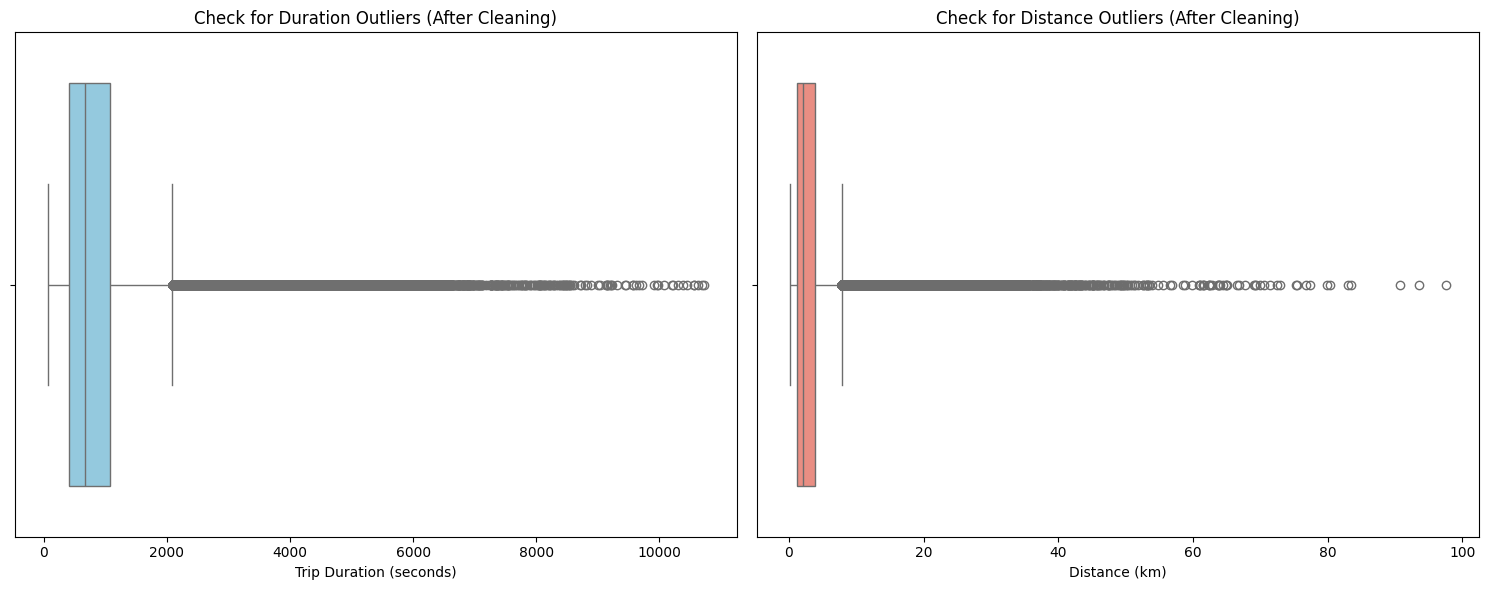

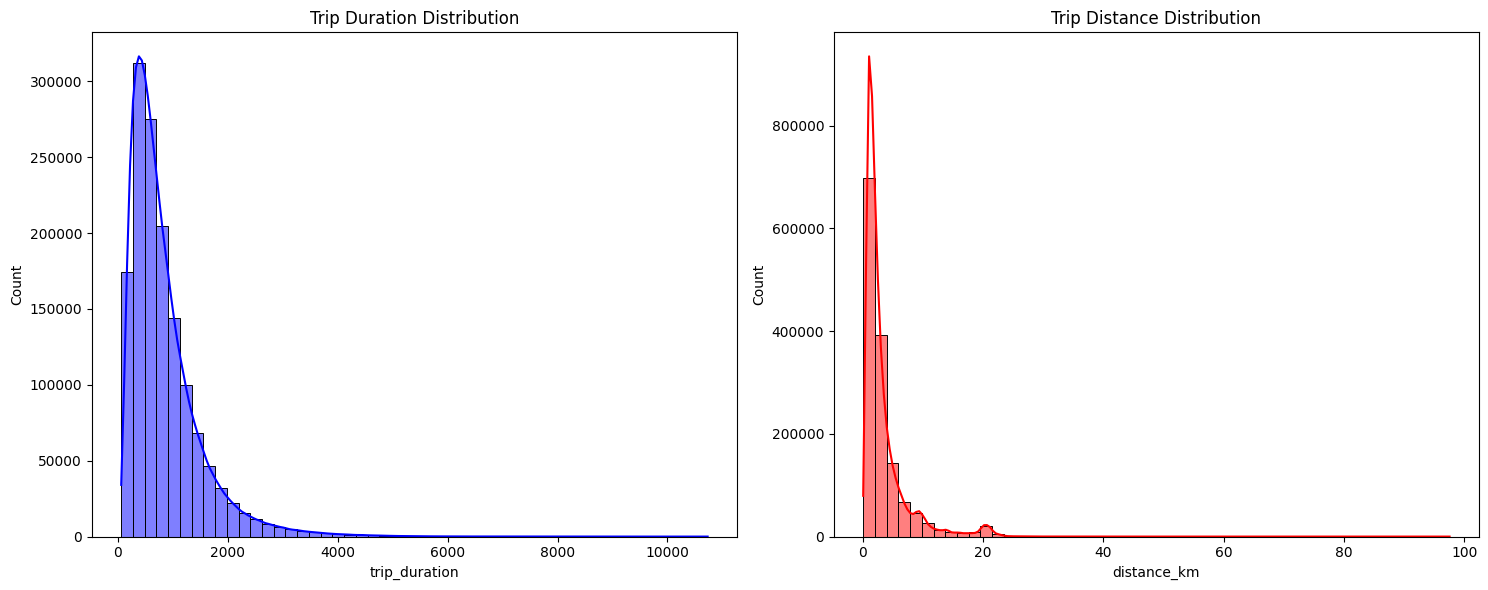

In [639]:
# Create a figure with 2 subplots (one for Duration, one for Distance)
plt.figure(figsize=(15, 6))

# 1. Boxplot for Trip Duration
plt.subplot(1, 2, 1)
sns.boxplot(x=df['trip_duration'], color='skyblue')
plt.title('Check for Duration Outliers (After Cleaning)')
plt.xlabel('Trip Duration (seconds)')

# 2. Boxplot for Trip Distance
plt.subplot(1, 2, 2)
sns.boxplot(x=df['distance_km'], color='salmon')
plt.title('Check for Distance Outliers (After Cleaning)')
plt.xlabel('Distance (km)')

plt.tight_layout()
plt.show()

# 3. Histogram to see the distribution of cleaned data
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['trip_duration'], bins=50, kde=True, color='blue')
plt.title('Trip Duration Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['distance_km'], bins=50, kde=True, color='red')
plt.title('Trip Distance Distribution')

plt.tight_layout()
plt.show()

## Feature Extraction --> ***Anas***

In [640]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day
873505,id0928710,2,2016-01-22 15:18:24,2016-01-22 15:20:32,2,-73.986008,40.758038,-73.990204,40.751678,N,128,0.790516,15,Friday
1020009,id1580444,1,2016-05-26 00:12:13,2016-05-26 00:18:07,2,-73.984657,40.736660,-73.995041,40.743820,N,354,1.182878,0,Thursday
811966,id3375418,2,2016-04-16 09:21:56,2016-04-16 09:39:10,1,-73.990021,40.687519,-73.964882,40.755589,N,1034,7.859875,9,Saturday


### Rush Hour Feature
This feature checks if the trip happened during peak traffic hours (morning or evening).  
It helps the model understand traffic impact on trip duration.

In [641]:
# df['rush_hour'] = df['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)

#### Rush Hour and Congestion Analysis

| Feature | Time Window | Rationale | Data-Driven Insight |
|---------|-------------|-----------|-------------------|
| **afternoon_peak** | 14–16 | True peak congestion period | Pivot table showed 14–16 as genuine peak (~1000–1023s avg) |
| **midday_busy** | 10–15 | Extended midday congestion window | Broader coverage of daytime traffic (10–15 range) |
| **evening_rush** | 17–21 | Evening commute (deprecated) | Declining phase; NOT the actual peak—already falling from afternoon max |

#### Key Findings

- **Weekday vs Weekend Contrast:** Weekday patterns show clear morning and afternoon peaks; weekends have flatter, elevated evening durations
- **Thursday/Friday Effect:** Thu/Fri consistently ~15% longer than Mon/Tue at same hour
- **Why Not 17–21?** Pivot analysis revealed this window is already in the descending phase; 14–16 captures the true congestion maximum
- **Hour 10 Observation:** Still shows ~925s average—justifies extending morning window to include it

In [642]:
# ── Temporal Feature Engineering ──────────────────────────────────────────────
# Based on empirical analysis of avg trip duration from pivot table:
#   - Weekday peak congestion:  14–16  (~1000–1023s avg)
#   - Weekday morning traffic:   7–10  (~800–920s avg)
#   - Weekend pattern: opposite shape — evening stays elevated, morning is fast
#   - Thursday/Friday consistently ~15% longer than Mon/Tue at same hour

# 1. Weekend flag
df['is_weekend'] = (df['pickup_datetime'].dt.dayofweek >= 5).astype(int)
is_weekday = ~df['is_weekend'].astype(bool)

# 2. Day of week (0=Mon ... 6=Sun) — captures Thu/Fri effect pivot table revealed
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

# 3. Data-driven congestion windows (from pivot table, NOT assumptions)
df['afternoon_peak']  = (is_weekday & df['pickup_hour'].between(14, 16)).astype(int)

# 4. DROP the old rush_hour — it was pointing at 17–21 which pivot showed
#    is already the DECLINING phase, not the peak
#    hour_sin + hour_cos + day_of_week replace it more faithfully

# 5. Sanity check — print mean duration per new flag to validate
print("Morning Rush mean duration (seconds):")
print("\nAfternoon Peak mean duration (seconds):")
print(df.groupby('afternoon_peak')['trip_duration'].mean().to_string())
print("\nWeekend mean duration (seconds):")
print(df.groupby('is_weekend')['trip_duration'].mean().to_string())
print("\nDay of Week mean duration (seconds):")
print(df.groupby('day_of_week')['trip_duration'].mean().to_string())

Morning Rush mean duration (seconds):

Afternoon Peak mean duration (seconds):
afternoon_peak
0     823.493468
1    1010.736442

Weekend mean duration (seconds):
is_weekend
0    868.877502
1    776.317411

Day of Week mean duration (seconds):
day_of_week
0    815.551214
1    860.560675
2    884.636405
3    903.248726
4    872.714970
5    783.368209
6    768.339055


In [643]:
# Data says peak congestion is 14-16 on weekdays, not 17-22
is_weekday = ~df['is_weekend'].astype(bool)

df['afternoon_peak'] = (is_weekday & df['pickup_hour'].between(14, 16)).astype(int)

### Trip Direction
This feature calculates the direction of the trip using pickup and dropoff coordinates.  
It may help capture movement patterns across the city.  
It is computed by taking the arctangent (atan2) of the difference in latitude (Y-axis) and longitude (X-axis) between dropoff and pickup points to obtain the trip angle.


In [644]:
df['direction'] = np.arctan2(
    df['dropoff_latitude'] - df['pickup_latitude'],
    df['dropoff_longitude'] - df['pickup_longitude']
)

### Average Speed
This feature estimates the trip speed (km/h) based on distance and duration.  
It helps identify abnormal trips and traffic conditions.

In [645]:
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

##### Speed Feature (For Analysis Only)

In this step, we calculate the average speed of each trip using distance and trip duration.

However, this feature is not used for model training.

The reason is that speed is calculated using the target variable (trip_duration). This creates a problem called data leakage, where the model indirectly gets access to the answer it is supposed to predict.

If we include speed as a feature, the model can easily infer the trip duration, leading to unrealistically high performance that does not reflect real-world behavior.

Instead, we use this feature for:
- Data Cleaning: to detect and remove unrealistic trips (e.g., extremely high or very low speeds)
- Exploratory Data Analysis (EDA): to better understand traffic patterns and trip behavior

This ensures that our model remains fair, realistic, and generalizable.

In [646]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh
556031,id0758261,1,2016-03-08 19:40:25,2016-03-08 19:54:13,1,-73.988945,40.753197,-74.013893,40.713703,N,828,4.868665,19,Tuesday,0,1,0,-2.1342,21.168109


### Time Features
We extract if the trip is on a weekend and the month of the trip.  
This helps capture seasonal and weekly patterns.

In [647]:
# df['is_weekend'] = df['pickup_datetime'].dt.dayofweek >= 5
df['month'] = df['pickup_datetime'].dt.month

### Distance per Passenger
This feature divides trip distance by number of passengers.  
It may reflect ride-sharing patterns or trip efficiency.

In [648]:
df['distance_per_passenger'] = df['distance_km'] / df['passenger_count']

### Log Transformation of Duration
We apply log transformation to reduce Skewed Distribution in trip duration.  
The goal is removing outliers.

In [649]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])

### Location Clustering (KMeans)

In this step, we apply clustering on the pickup and dropoff coordinates to group similar locations into clusters.

Instead of using raw latitude and longitude values directly, we transform them into cluster labels. This helps simplify the spatial information and makes it easier for the model to understand location-based patterns.

The main idea is that nearby locations usually share similar traffic conditions and travel behavior. For example, trips starting in the same area (like city center or airport) often have similar durations.

By grouping coordinates into clusters, we allow the model to learn:
- differences between regions
- traffic behavior in each area
- patterns related to specific zones

This approach improves model performance because it reduces noise in raw coordinates and captures meaningful geographic structure in the data.

In [650]:
coords = pd.concat([
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    }),
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
])

In [651]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(coords_scaled)

KMeans(n_clusters=5, random_state=42)

In [652]:
pickup_scaled = scaler.transform(
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    })
)
df['pickup_cluster'] = kmeans.predict(pickup_scaled)


dropoff_scaled = scaler.transform(
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
)
df['dropoff_cluster'] = kmeans.predict(dropoff_scaled)

In [653]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster
926667,id2789581,1,2016-02-20 05:09:25,2016-02-20 05:23:19,2,-73.987373,40.765469,-73.937546,40.850357,N,834,10.328836,5,Saturday,1,5,0,1.040008,44.584903,2,5.164418,6.727432,1,4
850677,id0033531,2,2016-02-16 14:50:40,2016-02-16 15:04:34,1,-73.951988,40.777611,-73.973938,40.747540,N,834,3.820770,14,Tuesday,0,1,1,-2.201325,16.492531,2,3.820770,6.727432,4,1
1048183,id2693293,2,2016-02-19 11:07:13,2016-02-19 11:25:42,5,-73.982384,40.777306,-73.981850,40.750156,N,1109,3.019188,11,Friday,0,4,0,-1.551128,9.800792,2,0.603838,7.012115,4,1


#### Feature Engineering Ashraf
- handle some features that was added

In [654]:
df.groupby('afternoon_peak')['trip_duration'].mean()

afternoon_peak
0     823.493468
1    1010.736442
Name: trip_duration, dtype: float64

In [655]:
df.groupby('afternoon_peak')[['trip_duration', 'distance_km', 'speed_kmh']].mean()

,trip_duration,distance_km,speed_kmh
afternoon_peak,,,
0,823.493468,3.475090,14.800149
1,1010.736442,3.448496,11.649467


In [656]:
# Calculate Manhattan Distance
df['manhattan_distance_km'] = (
    np.abs(df['pickup_latitude'] - df['dropoff_latitude']) +
    np.abs(df['pickup_longitude'] - df['dropoff_longitude'])
) * 111  # Approximate conversion factor for degrees to km

In [657]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km
993428,id1838647,2,2016-03-17 18:02:33,2016-03-17 18:14:49,1,-73.982399,40.768280,-73.961884,40.771992,N,736,1.776258,18,Thursday,0,3,0,0.178986,8.688218,3,1.776258,6.602588,1,4,2.689213
12073,id0837672,1,2016-02-27 13:15:45,2016-02-27 13:24:15,1,-74.001892,40.737808,-73.994637,40.761253,N,510,2.677667,13,Saturday,1,5,0,1.270675,18.901177,2,2.677667,6.236370,0,1,3.407776
710346,id3337468,1,2016-03-26 13:23:00,2016-03-26 13:38:33,2,-73.970047,40.757423,-73.996567,40.725723,N,933,4.173333,13,Saturday,1,5,0,-2.267449,16.102891,3,2.086666,6.839476,1,0,6.462410
59740,id2457299,2,2016-02-12 07:40:34,2016-02-12 08:01:55,1,-73.961266,40.780346,-73.991745,40.730206,N,1281,6.138049,7,Friday,0,4,0,-2.116991,17.249786,2,6.138049,7.156177,4,0,8.948799
1086967,id0649495,2,2016-06-14 14:51:00,2016-06-14 14:58:26,1,-73.989120,40.747906,-73.995178,40.733986,N,446,1.629784,14,Tuesday,0,1,1,-1.981264,13.155204,6,1.629784,6.102559,1,0,2.217510


- Convert `arctan2` angles to cardinal buckets (N, S, E, W) to avoid circular continuity issues in models
- One-hot encode `df['cardinal_direction']` for clean, orthogonal features compatible with linear and tree-based models
- Aligns with NYC street grid: Avenues (N/S) and Streets (E/W) have distinct traffic dynamics models can learn separately
- Eliminates edge-case confusion at angle boundaries (e.g., π vs -π both map to West)
- Improves model interpretability: coefficients or splits correspond to intuitive geographic directions

In [658]:
# arctan2 {df['direction']} to north, east, south, west
def direction_to_cardinal(angle):
    if -np.pi/4 <= angle < np.pi/4:
        return 'East'
    elif np.pi/4 <= angle < 3*np.pi/4:
        return 'North'
    elif -3*np.pi/4 <= angle < -np.pi/4:
        return 'South'
    else:
        return 'West'

In [659]:
df['direction'] = np.degrees(df['direction'])
df['cardinal_direction'] = df['direction'].apply(direction_to_cardinal)

In [660]:
df.groupby('cardinal_direction')['trip_duration'].mean()

cardinal_direction
East     840.704188
North    867.315830
South    815.314104
West     842.491458
Name: trip_duration, dtype: float64

In [661]:
df.groupby(['afternoon_peak', 'cardinal_direction'])['trip_duration'].mean().unstack()

cardinal_direction,East,North,South,West
afternoon_peak,,,,
0,825.269749,851.967459,807.137723,823.438518
1,997.369021,1019.528662,903.037313,1011.047442


In [662]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction
1183813,id1036138,2,2016-05-14 09:15:34,2016-05-14 09:53:00,2,-73.963333,40.766048,-73.954933,40.807709,N,2246,4.686086,9,Saturday,1,5,0,78.600302,7.51109,5,2.343043,7.717351,4,4,5.55669,West


### Pickup hour analysis

In [663]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction
648587,id1025596,2,2016-05-04 07:49:29,2016-05-04 07:59:11,1,-73.980377,40.775131,-73.984764,40.767715,N,582,0.903566,7,Wednesday,0,2,0,-120.607022,5.589068,5,0.903566,6.368187,4,1,1.310097,West


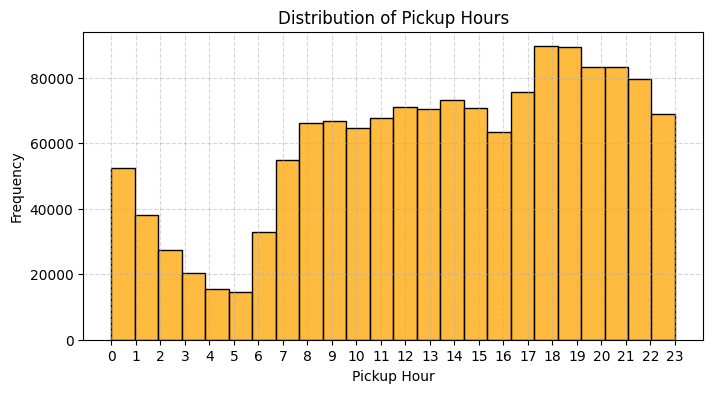

In [664]:
#plot hist for pickup hours
plt.figure(figsize=(8, 4))
sns.histplot(df['pickup_hour'], bins=24, kde=False, color='orange')
plt.title('Distribution of Pickup Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Frequency')
plt.xticks(range(24), rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

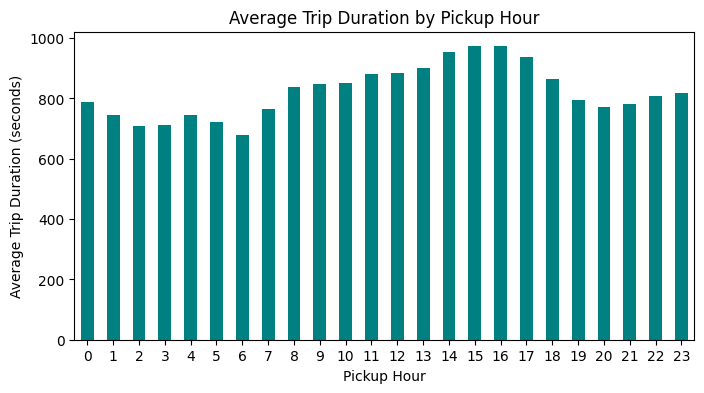

In [665]:
df.groupby('pickup_hour')['trip_duration'].mean().plot(kind='bar', figsize=(8, 4), color='teal')
plt.title('Average Trip Duration by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(rotation=0)
plt.show()

In [666]:
df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour']/24)

In [667]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos
937866,id3499825,2,2016-05-15 20:46:54,2016-05-15 20:59:36,1,-73.982925,40.748138,-73.944626,40.800339,N,762,6.640204,20,Sunday,1,6,0,53.732369,31.371043,5,6.640204,6.637258,1,4,10.045486,West,-0.866025,0.5


In [668]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos
254044,id3666728,1,2016-04-19 16:03:52,2016-04-19 16:50:20,1,-73.805161,40.6507,-73.98748,40.750462,N,2788,18.95462,16,Tuesday,0,1,1,151.31333,24.475119,4,18.95462,7.933438,2,1,31.311058,West,-0.866025,-0.5


#### Trip duration into 3 classes short, medium, long for thresholds [>600>1200] seconds.

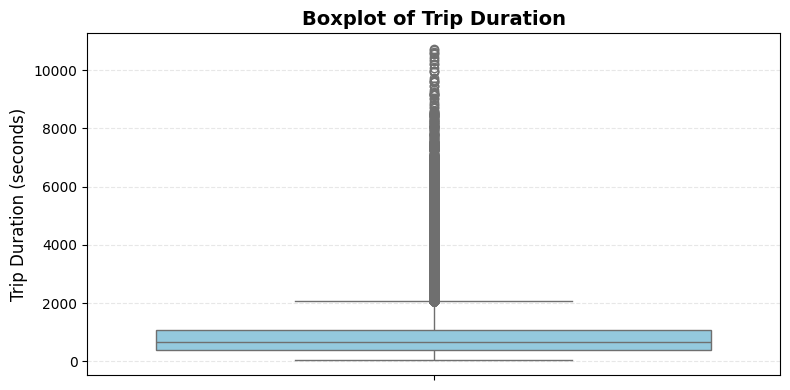

In [669]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, y='trip_duration', color='skyblue')
plt.title('Boxplot of Trip Duration', fontsize=14, fontweight='bold')
plt.ylabel('Trip Duration (seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [670]:
df['trip_duration'].describe().T

count    1.440222e+06
mean     8.424850e+02
std      6.569905e+02
min      6.100000e+01
25%      4.020000e+02
50%      6.660000e+02
75%      1.077000e+03
max      1.073100e+04
Name: trip_duration, dtype: float64

In [671]:
def categorize_duration(seconds):
    if seconds < 600:      
        return 'short'
    elif seconds < 1200:   
        return 'medium'
    else:                  
        return 'long'

df['tripduration_cat'] = df['trip_duration'].apply(categorize_duration)

print(df['tripduration_cat'].value_counts())

tripduration_cat
short     638468
medium    509020
long      292734
Name: count, dtype: int64


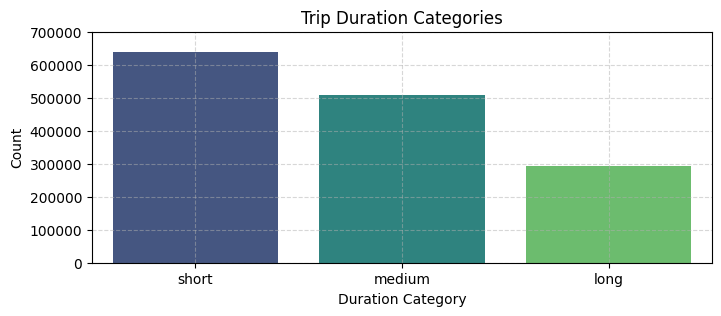

In [672]:
plt.figure(figsize=(8, 3))
sns.barplot(x=df['tripduration_cat'].value_counts().index, y=df['tripduration_cat'].value_counts().values, palette='viridis')
plt.title('Trip Duration Categories')
plt.xlabel('Duration Category')
plt.ylabel('Count')
plt.yticks(np.arange(0, df['tripduration_cat'].value_counts().max() + 90000, 100000))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


- **Stratified Split:** Use `df['tripduration_cat']` as the `stratify` argument in `train_test_split` to ensure proportional class distribution in both splits.
- **Resample Training Only:** Apply `RandomUnderSampler` exclusively to `X_train` and `y_train` to balance the training classes.
- **Preserve Test Set:** Leave the test set completely untouched; **never** apply resampling or modifications to it.
- **Drop Pre-Modeling:** Remove the `tripduration_cat` column from both the resampled training set and the original test set before model training/evaluation.

In [673]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,afternoon_peak,direction,speed_kmh,month,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,manhattan_distance_km,cardinal_direction,hour_sin,hour_cos,tripduration_cat
831432,id1080243,1,2016-01-13 18:49:21,2016-01-13 18:58:34,1,-73.973274,40.755539,-73.962502,40.763981,N,553,1.305529,18,Wednesday,0,2,0,38.083677,8.498924,1,1.305529,6.317165,1,1,2.132824,West,-1.000000,-1.836970e-16,short
329035,id2214963,2,2016-04-16 10:57:49,2016-04-16 11:04:42,1,-73.966904,40.769772,-73.977493,40.758759,N,413,1.514933,10,Saturday,1,5,0,-133.877094,13.205229,4,1.514933,6.025866,4,1,2.397892,West,0.500000,-8.660254e-01,short
1133583,id0068743,1,2016-01-20 07:06:05,2016-01-20 07:15:32,1,-74.001434,40.730949,-73.990547,40.760288,N,567,3.388803,7,Wednesday,0,2,0,69.640962,21.516211,1,3.388803,6.342121,0,1,4.465084,West,0.965926,-2.588190e-01,short


##### Some Featuers needed to be dropped as they were Superseded by other features or was just for EDA, split data and So on.

In [674]:
# df.drop(columns=['pickup_hour','month','direction','tripduration_cat','pickup_day'], inplace=True)